### Import Libraries

In [4]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


2026-05-03 15:12:52.360529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777821172.532523      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777821172.590754      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777821173.031591      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777821173.031635      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777821173.031638      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### Set Dataset Path


In [5]:
DATASET_ROOT = Path("/kaggle/input/datasets/ritikarakhalmagar/brain-tumor-classification/Brain Tumor Classifcation")

TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

CLASS_DISPLAY_NAMES = {
    "glioma_tumor": "Glioma Tumor",
    "meningioma_tumor": "Meningioma Tumor",
    "normal": "Normal",
    "pituitary_tumor": "Pituitary Tumor"
}

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

print("Dataset exists:", DATASET_ROOT.exists())
print("Train folder exists:", TRAIN_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())


Dataset exists: True
Train folder exists: True
Test folder exists: True


### Collect Image Records


In [6]:
def collect_image_records(dataset_root):
    records = []

    for split in ["train", "test"]:
        split_dir = dataset_root / split

        for class_dir in sorted(split_dir.iterdir()):
            if class_dir.is_dir():
                for image_path in sorted(class_dir.glob("*.jpg")):
                    records.append({
                        "split": split,
                        "class_name": class_dir.name,
                        "class_display": CLASS_DISPLAY_NAMES[class_dir.name],
                        "file_path": str(image_path)
                    })

    return pd.DataFrame(records)


df = collect_image_records(DATASET_ROOT)

print("Total image files:", len(df))
display(df.head())

Total image files: 3096


,split,class_name,class_display,file_path
0,train,glioma_tumor,Glioma Tumor,/kaggle/input/datasets/ritikarakhalmagar/brain...
1,train,glioma_tumor,Glioma Tumor,/kaggle/input/datasets/ritikarakhalmagar/brain...
2,train,glioma_tumor,Glioma Tumor,/kaggle/input/datasets/ritikarakhalmagar/brain...
3,train,glioma_tumor,Glioma Tumor,/kaggle/input/datasets/ritikarakhalmagar/brain...
4,train,glioma_tumor,Glioma Tumor,/kaggle/input/datasets/ritikarakhalmagar/brain...


### Check Corrupted Images


In [7]:
def is_readable_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


df["readable"] = df["file_path"].apply(is_readable_image)

total_images = len(df)
readable_images = int(df["readable"].sum())
corrupted_images = total_images - readable_images

print("Total JPG images:", total_images)
print("Readable images:", readable_images)
print("Corrupted images:", corrupted_images)

clean_df = df[df["readable"] == True].reset_index(drop=True)

Total JPG images: 3096
Readable images: 3068
Corrupted images: 28


## 2.5 Part A Designing and Analyzing Convolutional Neural Networks from Scratch.

### 2.5.1 Data Understanding, Analysis, Visualization and Cleaning:

### What does the dataset represent? Provide a brief description.

The dataset represents MRI brain images used for brain tumor classification. Each image belongs to one of four categories: glioma tumor, meningioma tumor, pituitary tumor, or normal.


### How many total images are in the dataset?

The dataset contains 3096 JPG image files in total. During preprocessing, 28 corrupted images were identified. After removing corrupted images, 3068 readable images remained for analysis and model training.


### What is the distribution of images across different classes?

In [8]:
class_distribution = (
    clean_df.groupby(["split", "class_display"])
    .size()
    .reset_index(name="count")
)

display(class_distribution)

,split,class_display,count
0,test,Glioma Tumor,181
1,test,Meningioma Tumor,183
2,test,Normal,88
3,test,Pituitary Tumor,169
4,train,Glioma Tumor,713
5,train,Meningioma Tumor,723
6,train,Normal,343
7,train,Pituitary Tumor,668


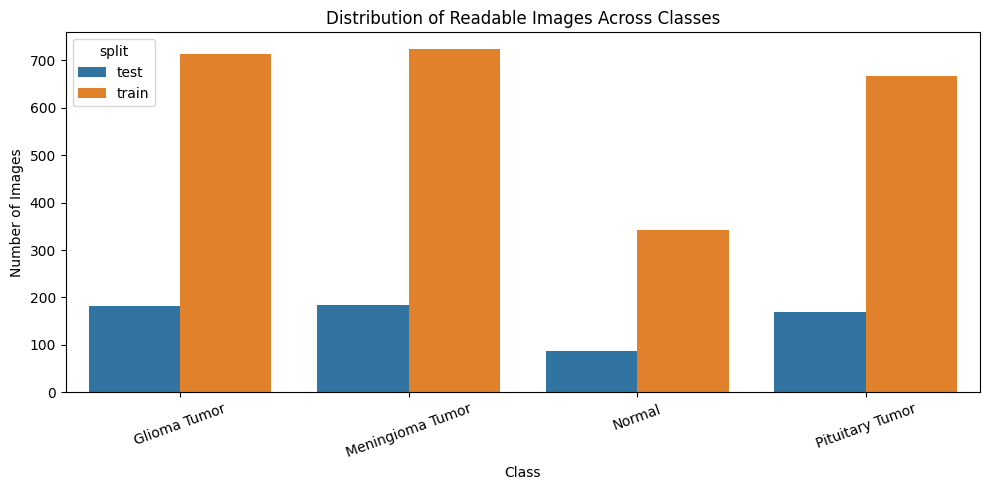

In [9]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=class_distribution,
    x="class_display",
    y="count",
    hue="split"
)

plt.title("Distribution of Readable Images Across Classes")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The dataset is imbalanced. The Normal class has fewer images than the tumor classes, so class weights are used during training.


### How is the dataset split into training and validation sets? Justify your choice.

In [10]:
train_full_df = clean_df[clean_df["split"] == "train"].copy().reset_index(drop=True)
test_df = clean_df[clean_df["split"] == "test"].copy().reset_index(drop=True)

class_names = sorted(clean_df["class_name"].unique())
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
index_to_class = {index: CLASS_DISPLAY_NAMES[class_name] for class_name, index in class_to_index.items()}

train_full_df["label"] = train_full_df["class_name"].map(class_to_index)
test_df["label"] = test_df["class_name"].map(class_to_index)

train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_full_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Class mapping:", index_to_class)
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

Class mapping: {0: 'Glioma Tumor', 1: 'Meningioma Tumor', 2: 'Normal', 3: 'Pituitary Tumor'}
Training images: 1957
Validation images: 490
Testing images: 621


In [11]:
split_summary = pd.concat([
    train_df.assign(final_split="train"),
    val_df.assign(final_split="validation"),
    test_df.assign(final_split="test")
])

split_summary_table = (
    split_summary.groupby(["final_split", "class_display"])
    .size()
    .reset_index(name="count")
)

display(split_summary_table)

,final_split,class_display,count
0,test,Glioma Tumor,181
1,test,Meningioma Tumor,183
2,test,Normal,88
3,test,Pituitary Tumor,169
4,train,Glioma Tumor,570
5,train,Meningioma Tumor,578
6,train,Normal,275
7,train,Pituitary Tumor,534
8,validation,Glioma Tumor,143
9,validation,Meningioma Tumor,145


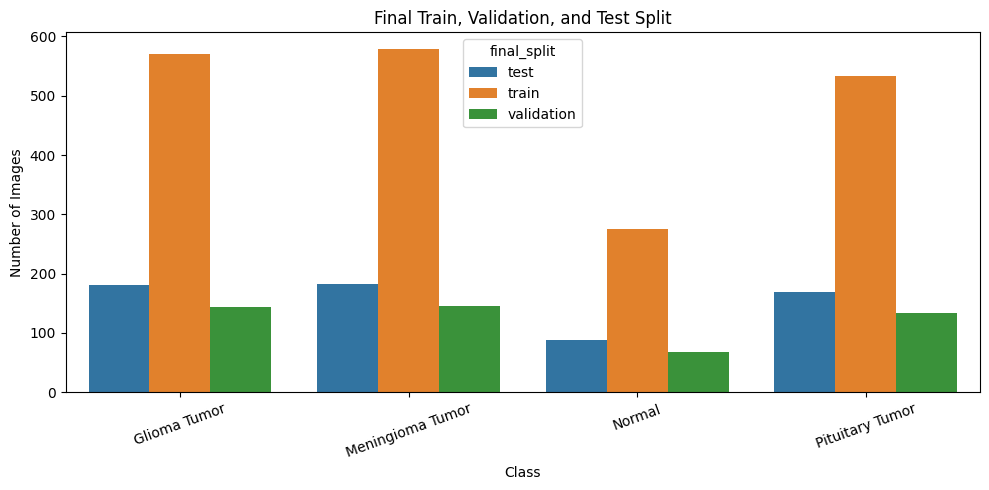

In [12]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=split_summary_table,
    x="class_display",
    y="count",
    hue="final_split"
)

plt.title("Final Train, Validation, and Test Split")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The dataset already contains separate train and test folders. The readable training images were split into 80% training and 20% validation. Stratified splitting was used to keep all four classes represented in both sets. The test set was kept separate for final evaluation.


### What preprocessing techniques (e.g., resizing, normalization) were applied?

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def make_dataset(dataframe, shuffle=False):
    paths = dataframe["file_path"].values
    labels = dataframe["label"].values.astype("int32")

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Testing batches:", len(test_ds))

I0000 00:00:1777821221.513248      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777821221.519487      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training batches: 62
Validation batches: 16
Testing batches: 20


The images were resized to 224 × 224 pixels so that all inputs have the same shape. Pixel values were normalized from the 0-255 range to the 0-1 range. This helps the CNN train more efficiently and improves numerical stability.


### What data generators, if any, were used for preprocessing and augmentation?

In [14]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03, seed=SEED),
    layers.RandomZoom(0.10, seed=SEED),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05, seed=SEED),
    layers.RandomBrightness(factor=0.10, seed=SEED),
    layers.GaussianNoise(0.02),
], name="training_augmentation")

A TensorFlow data pipeline was used for loading, batching, and prefetching the images. Keras augmentation layers and ImageDataGenerator were used to create augmented training samples. The augmentation was applied only to the training images.

### If data augmentation was applied, provide visualizations of sample augmented images.


Using image: /kaggle/input/datasets/ritikarakhalmagar/brain-tumor-classification/Brain Tumor Classifcation/train/glioma_tumor/G_622.jpg


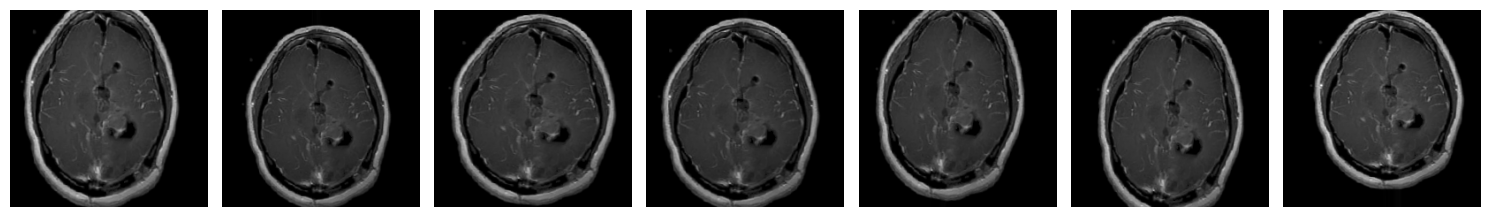

In [15]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Pick the first image from the first class folder
first_class_path = TRAIN_DIR / class_names[0]

image_files = [
    f for f in os.listdir(first_class_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

if not image_files:
    raise ValueError(f"No image files found in {first_class_path}")

sample_img_path = first_class_path / image_files[0]
print("Using image:", sample_img_path)

# Load and preprocess image
img = image.load_img(sample_img_path, target_size=IMG_SIZE)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    brightness_range=[0.9, 1.1],
    fill_mode="nearest"
)

# Generate augmented images
aug_iter = datagen.flow(x, batch_size=1)

# Display augmented images
fig, ax = plt.subplots(1, 7, figsize=(15, 5))

for i in range(7):
    batch = next(aug_iter)
    ax[i].imshow(batch[0].astype("uint8"))
    ax[i].axis("off")

plt.tight_layout()
plt.show()


The augmented images show modified versions of the original MRI image. Small rotation, shifting, zoom, and brightness changes were used. These transformations increase image variation and help reduce overfitting during training.

## 2.5.2 Design, Train, and Evaluate a Baseline Model


### Model Architecture


In [16]:
def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


baseline_model = build_baseline_cnn(
    input_shape=IMG_SIZE + (3,),
    num_classes=len(class_names)
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,825,028 (98.51 MB)

 Trainable params: 25,825,028 (98.51 MB)

 Non-trainable params: 0 (0.00 B)

The baseline CNN contains three convolutional layers, each followed by a max pooling layer. The convolution layers use 3 × 3 kernels with 32, 64, and 128 filters. ReLU activation is used in the hidden layers.

The model also includes three fully connected layers and a softmax output layer. Softmax is used because the task has four possible classes.

### Model Training


In [17]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(train_df["label"].unique())),
    y=train_df["label"].values
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print(class_weights)

{0: np.float64(0.8583333333333333), 1: np.float64(0.8464532871972318), 2: np.float64(1.779090909090909), 3: np.float64(0.9161985018726592)}


In [18]:
start_time = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

baseline_training_time = time.time() - start_time

print("Baseline CNN training time:", baseline_training_time, "seconds")

Epoch 1/20


I0000 00:00:1777821226.291132     134 service.cc:152] XLA service 0x796308011360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777821226.291203     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777821226.291209     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777821226.840425     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/62 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1458 - loss: 1.4149

I0000 00:00:1777821232.033704     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3203 - loss: 1.3253

2026-05-03 15:13:56.156517: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:13:56.300266: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 141ms/step - accuracy: 0.3218 - loss: 1.3233 - val_accuracy: 0.5469 - val_loss: 1.1313
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5450 - loss: 0.9943 - val_accuracy: 0.6551 - val_loss: 0.9258
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.6946 - loss: 0.7198 - val_accuracy: 0.6694 - val_loss: 0.8796
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.7682 - loss: 0.5408 - val_accuracy: 0.6776 - val_loss: 0.7934
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.7999 - loss: 0.4638 - val_accuracy: 0.7327 - val_loss: 0.7506
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.8683 - loss: 0.3336 - val_accuracy: 0.7531 - val_loss: 0.7516
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.8934 - loss: 0.2675 - val_accuracy: 0.7612 - val_loss: 0.7759
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9294 - loss: 0.1881 - val_accuracy: 0.7918 - val_loss: 

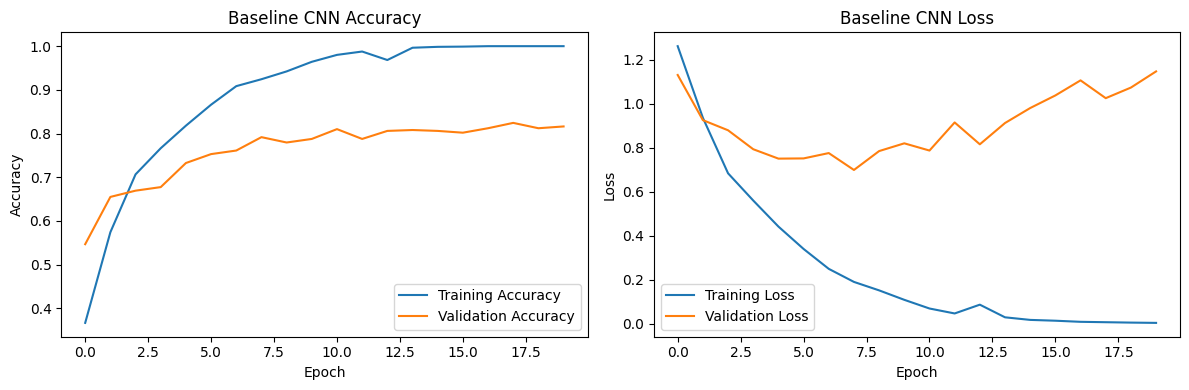

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(baseline_history.history["accuracy"], label="Training Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(baseline_history.history["loss"], label="Training Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The baseline model was trained using the Adam optimizer and sparse categorical crossentropy loss. Training and validation accuracy/loss curves were plotted to observe the learning behavior of the model.


### Model Evaluation

In [20]:
def get_predictions(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        predicted_classes = np.argmax(predictions, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted_classes)

    return np.array(y_true), np.array(y_pred)


baseline_y_true, baseline_y_pred = get_predictions(baseline_model, test_ds)

In [21]:
target_names = [index_to_class[i] for i in range(len(index_to_class))]

print("Baseline CNN Classification Report:")
print(classification_report(baseline_y_true, baseline_y_pred, target_names=target_names))

Baseline CNN Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.86      0.80      0.83       181
Meningioma Tumor       0.78      0.79      0.79       183
          Normal       0.82      0.80      0.81        88
 Pituitary Tumor       0.86      0.92      0.89       169

        accuracy                           0.83       621
       macro avg       0.83      0.83      0.83       621
    weighted avg       0.83      0.83      0.83       621



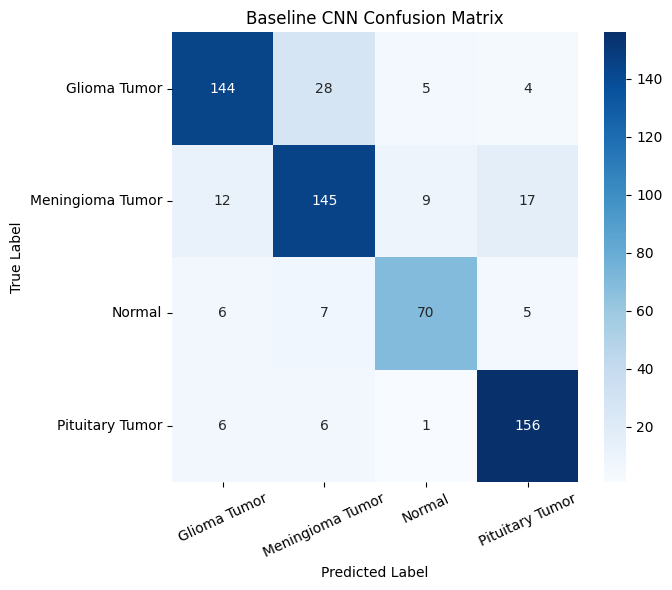

In [22]:
baseline_cm = confusion_matrix(baseline_y_true, baseline_y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=25)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Inference on Sample Images


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


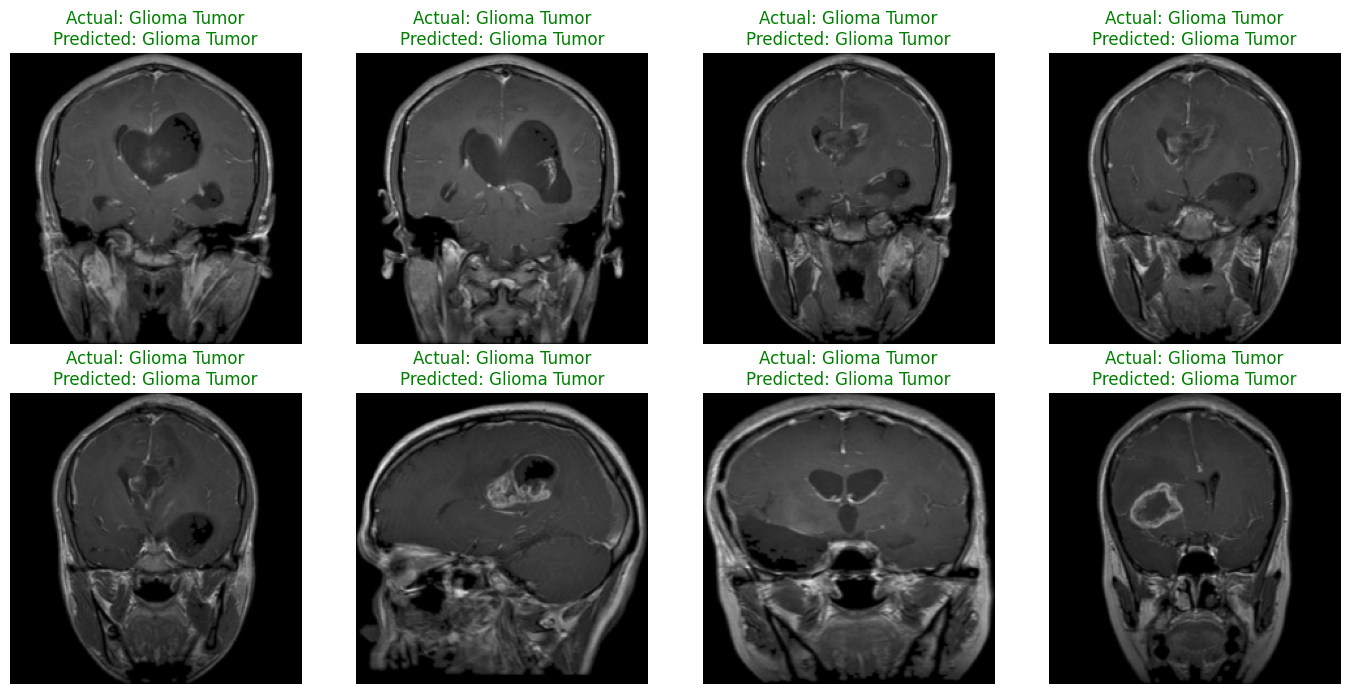

In [23]:
for images, labels in test_ds.take(1):
    predictions = baseline_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(14, 7))

    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])

        actual = index_to_class[int(labels[i])]
        predicted = index_to_class[int(predicted_labels[i])]

        color = "green" if actual == predicted else "red"
        plt.title(f"Actual: {actual}\nPredicted: {predicted}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Sample predictions were plotted to compare actual and predicted labels. Green titles show correct predictions, while red titles show incorrect predictions.


### Key Obversations about Model Perfomance

The baseline CNN achieved 83% accuracy on the test set. Pituitary tumor had the best performance with an F1-score of 0.89. Meningioma tumor had the lowest F1-score of 0.79, showing that it was slightly more difficult for the model to classify.

Overall, the baseline CNN performed reasonably well, but there is still room for improvement using a deeper model and transfer learning.


## 2.5.3 Deeper Architecture with Regularization Layer

### Model Architecture

In [24]:
def build_deeper_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.40),
        layers.Dense(128, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


deeper_model = build_deeper_cnn(
    input_shape=IMG_SIZE + (3,),
    num_classes=len(class_names)
)

deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,89

 Total params: 26,012,580 (99.23 MB)

 Trainable params: 26,011,684 (99.23 MB)

 Non-trainable params: 896 (3.50 KB)

The deeper CNN extends the baseline model by using more convolutional layers. It has six convolutional layers, which is double the baseline CNN.

Batch normalization and dropout were added as regularization techniques. Batch normalization helps stabilize training, while dropout helps reduce overfitting.

### Model Training

In [25]:
start_time = time.time()

deeper_history = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

deeper_training_time = time.time() - start_time

print("Deeper CNN training time:", deeper_training_time, "seconds")

Epoch 1/20


2026-05-03 15:15:26.115284: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:15:26.271501: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:15:29.146376: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:15:29.439104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:15:29.692567: E external/local_xla/xla/service

61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.3346 - loss: 3.6444

2026-05-03 15:15:49.715580: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:15:49.862711: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:15:50.778133: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:15:51.055307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 385ms/step - accuracy: 0.3372 - loss: 3.6047 - val_accuracy: 0.2735 - val_loss: 2.8034
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.5255 - loss: 1.1276 - val_accuracy: 0.3776 - val_loss: 3.1656
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.6015 - loss: 0.9402 - val_accuracy: 0.2878 - val_loss: 4.5795
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - accuracy: 0.6224 - loss: 0.8802 - val_accuracy: 0.3020 - val_loss: 5.5206
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.6602 - loss: 0.7583 - val_accuracy: 0.3286 - val_loss: 4.6477
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.6762 - loss: 0.7200 - val_accuracy: 0.3755 - val_loss: 3.9801
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.7072 - loss: 0.6618 - val_accuracy: 0.4224 - val_loss: 2.8521
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.7544 - loss: 0.5868 - val_accuracy: 0.475

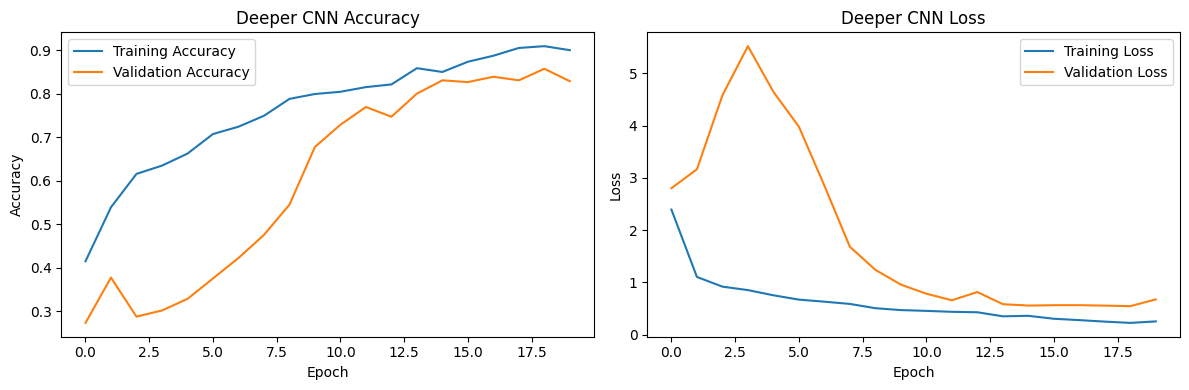

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(deeper_history.history["accuracy"], label="Training Accuracy")
plt.plot(deeper_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Deeper CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(deeper_history.history["loss"], label="Training Loss")
plt.plot(deeper_history.history["val_loss"], label="Validation Loss")
plt.title("Deeper CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Compare its training time and loss curves against the baseline model.

The baseline CNN trained in about 87.97 seconds, while the deeper CNN trained in about 236.16 seconds. The deeper CNN required more time because it had more convolutional layers, batch normalization, and dropout layers.

For the baseline model, the final training accuracy was 100%, but validation accuracy was 81.63%. Its training loss was very low at 0.0030, while validation loss was higher at 1.1476. This shows overfitting.

For the deeper CNN, the final training accuracy was 91.05%, and validation accuracy was 82.86%. Its training loss was 0.2450, and validation loss was 0.6761. Compared with the baseline, the deeper CNN reduced overfitting and achieved slightly better validation performance, but it required much longer training time.

### Model Evaluation

In [27]:
deeper_y_true, deeper_y_pred = get_predictions(deeper_model, test_ds)

In [28]:
print("Deeper CNN Classification Report:")
print(classification_report(deeper_y_true, deeper_y_pred, target_names=target_names))

Deeper CNN Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.88      0.89       181
Meningioma Tumor       0.87      0.61      0.72       183
          Normal       0.65      0.95      0.77        88
 Pituitary Tumor       0.88      0.98      0.93       169

        accuracy                           0.84       621
       macro avg       0.83      0.85      0.83       621
    weighted avg       0.85      0.84      0.83       621



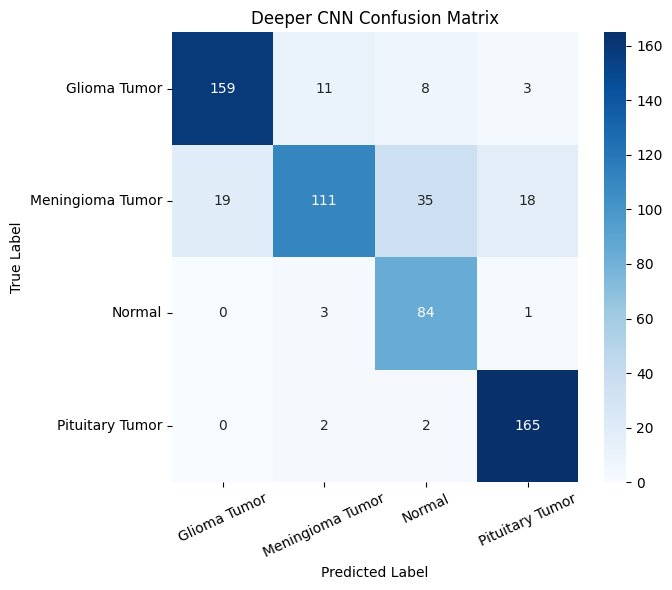

In [29]:
deeper_cm = confusion_matrix(deeper_y_true, deeper_y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    deeper_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Deeper CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=25)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Discuss improvements compared to the baseline model.

The deeper CNN achieved 84% test accuracy, while the baseline CNN achieved 83% test accuracy. Therefore, the deeper model slightly improved overall performance.

The deeper CNN performed best on pituitary tumor with an F1-score of 0.93 and also improved glioma tumor performance. However, meningioma tumor had the lowest recall of 0.61, showing that this class was still harder to classify.

Overall, adding more layers with batch normalization and dropout gave a small improvement, but the model still had difficulty distinguishing meningioma tumor images.

## 2.5.4 Experimentation and Comparative Analysis


### Baseline vs. Deeper Model Performance


In [30]:
baseline_accuracy = np.mean(baseline_y_true == baseline_y_pred)
deeper_accuracy = np.mean(deeper_y_true == deeper_y_pred)

performance_comparison = pd.DataFrame({
    "Model": ["Baseline CNN", "Deeper CNN"],
    "Test Accuracy": [baseline_accuracy, deeper_accuracy],
    "Training Time (seconds)": [baseline_training_time, deeper_training_time]
})

display(performance_comparison)

,Model,Test Accuracy,Training Time (seconds)
0,Baseline CNN,0.829308,87.972164
1,Deeper CNN,0.835749,236.163760


The baseline CNN achieved 82.93% test accuracy and trained in about 87.97 seconds. The deeper CNN achieved 83.57% test accuracy and trained in about 236.16 seconds.

The deeper CNN gave a small improvement in accuracy, but it required much longer training time. This shows that adding more layers slightly improved performance, but increased computational cost.

### Computational Efficiency

The baseline CNN was more computationally efficient because it trained much faster. The deeper CNN achieved slightly higher accuracy, but it required more training time because it had more convolutional layers, batch normalization, and dropout.

This shows a trade-off between model complexity and efficiency. The deeper model improved accuracy slightly, but the baseline model was faster and more efficient.

### Optimizer Analysis: SGD vs Adam

In [31]:
def build_deeper_cnn_with_optimizer(input_shape=(224, 224, 3), num_classes=4, optimizer_name="adam"):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.40),
        layers.Dense(128, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    if optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
    else:
        optimizer = keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [32]:
deeper_sgd_model = build_deeper_cnn_with_optimizer(
    input_shape=IMG_SIZE + (3,),
    num_classes=len(class_names),
    optimizer_name="sgd"
)

start_time = time.time()

deeper_sgd_history = deeper_sgd_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

deeper_sgd_training_time = time.time() - start_time

print("Deeper CNN with SGD training time:", deeper_sgd_training_time, "seconds")

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 25s 276ms/step - accuracy: 0.3235 - loss: 2.8792 - val_accuracy: 0.3490 - val_loss: 1.6585
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.5396 - loss: 1.0843 - val_accuracy: 0.3449 - val_loss: 2.0768
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.5966 - loss: 0.8956 - val_accuracy: 0.3388 - val_loss: 2.2903
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.6691 - loss: 0.7469 - val_accuracy: 0.3714 - val_loss: 2.0775
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.6667 - loss: 0.7232 - val_accuracy: 0.4000 - val_loss: 2.3926
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.6875 - loss: 0.6909 - val_accuracy: 0.4571 - val_loss: 2.1843
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.7597 - loss: 0.5780 - val_accuracy: 0.5163 - val_loss: 1.6416
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.7229 - loss: 0.5757 - val_accu

In [33]:
deeper_sgd_y_true, deeper_sgd_y_pred = get_predictions(deeper_sgd_model, test_ds)

print("Deeper CNN with SGD Classification Report:")
print(classification_report(deeper_sgd_y_true, deeper_sgd_y_pred, target_names=target_names))


Deeper CNN with SGD Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.86      0.83      0.85       181
Meningioma Tumor       0.78      0.79      0.79       183
          Normal       0.80      0.90      0.84        88
 Pituitary Tumor       0.94      0.90      0.92       169

        accuracy                           0.85       621
       macro avg       0.85      0.86      0.85       621
    weighted avg       0.85      0.85      0.85       621



The Adam optimizer result was taken from the deeper CNN trained earlier using the same architecture. The SGD optimizer was trained separately using the same model structure to compare optimizer performance.

In [34]:
deeper_sgd_accuracy = np.mean(deeper_sgd_y_true == deeper_sgd_y_pred)

optimizer_comparison = pd.DataFrame({
    "Optimizer": ["Adam", "SGD"],
    "Final Training Accuracy": [
        deeper_history.history["accuracy"][-1],
        deeper_sgd_history.history["accuracy"][-1]
    ],
    "Final Validation Accuracy": [
        deeper_history.history["val_accuracy"][-1],
        deeper_sgd_history.history["val_accuracy"][-1]
    ],
    "Test Accuracy": [
        deeper_accuracy,
        deeper_sgd_accuracy
    ],
    "Training Time (seconds)": [
        deeper_training_time,
        deeper_sgd_training_time
    ]
})

display(optimizer_comparison)

,Optimizer,Final Training Accuracy,Final Validation Accuracy,Test Accuracy,Training Time (seconds)
0,Adam,0.899847,0.828571,0.835749,236.163760
1,SGD,0.892182,0.848980,0.848631,214.425914


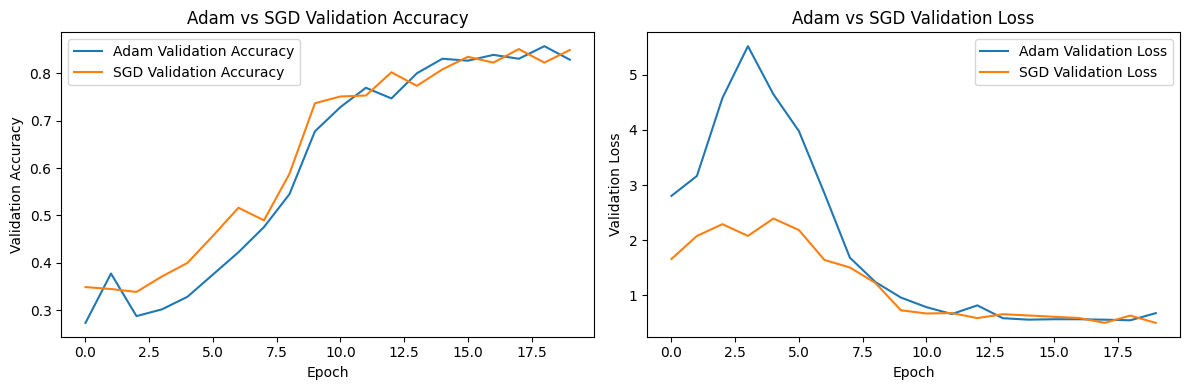

In [35]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(deeper_history.history["val_accuracy"], label="Adam Validation Accuracy")
plt.plot(deeper_sgd_history.history["val_accuracy"], label="SGD Validation Accuracy")
plt.title("Adam vs SGD Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(deeper_history.history["val_loss"], label="Adam Validation Loss")
plt.plot(deeper_sgd_history.history["val_loss"], label="SGD Validation Loss")
plt.title("Adam vs SGD Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Compare the impact of these optimizers on convergence speed and final performance.

Adam achieved 83.57% test accuracy, while SGD achieved 84.86% test accuracy. SGD also trained faster, taking about 214.43 seconds compared to Adam's 236.16 seconds.

In this experiment, SGD performed slightly better than Adam because it achieved higher validation accuracy, higher test accuracy, and lower training time. This shows that optimizer choice affected both convergence and final model performance.

### Ablation Study

In this ablation study, dropout is removed from the deeper CNN to observe how model performance changes.


In [36]:
def build_deeper_cnn_without_dropout(input_shape=(224, 224, 3), num_classes=4):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


no_dropout_model = build_deeper_cnn_without_dropout(
    input_shape=IMG_SIZE + (3,),
    num_classes=len(class_names)
)

no_dropout_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,012,580 (99.23 MB)

 Trainable params: 26,011,684 (99.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [37]:
start_time = time.time()

no_dropout_history = no_dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

no_dropout_training_time = time.time() - start_time

print("No Dropout CNN training time:", no_dropout_training_time, "seconds")

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 241ms/step - accuracy: 0.4681 - loss: 3.6022 - val_accuracy: 0.2959 - val_loss: 7.4036
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.8654 - loss: 0.3415 - val_accuracy: 0.2959 - val_loss: 8.2549
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.9557 - loss: 0.1232 - val_accuracy: 0.3796 - val_loss: 3.3984
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.9960 - loss: 0.0374 - val_accuracy: 0.3061 - val_loss: 2.1637
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.9971 - loss: 0.0209 - val_accuracy: 0.4020 - val_loss: 1.5676
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.9996 - loss: 0.0156 - val_accuracy: 0.4449 - val_loss: 1.3787
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9993 - loss: 0.0088 - val_accuracy: 0.5490 - val_loss: 1.2475
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accu

In [38]:
no_dropout_y_true, no_dropout_y_pred = get_predictions(no_dropout_model, test_ds)

print("No Dropout CNN Classification Report:")
print(classification_report(no_dropout_y_true, no_dropout_y_pred, target_names=target_names))

No Dropout CNN Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.86      0.87       181
Meningioma Tumor       0.84      0.82      0.83       183
          Normal       0.87      0.89      0.88        88
 Pituitary Tumor       0.92      0.96      0.94       169

        accuracy                           0.88       621
       macro avg       0.88      0.88      0.88       621
    weighted avg       0.88      0.88      0.88       621



In [39]:
no_dropout_accuracy = np.mean(no_dropout_y_true == no_dropout_y_pred)

ablation_comparison = pd.DataFrame({
    "Model": ["Deeper CNN with Dropout", "Deeper CNN without Dropout"],
    "Final Training Accuracy": [
        deeper_history.history["accuracy"][-1],
        no_dropout_history.history["accuracy"][-1]
    ],
    "Final Validation Accuracy": [
        deeper_history.history["val_accuracy"][-1],
        no_dropout_history.history["val_accuracy"][-1]
    ],
    "Test Accuracy": [
        deeper_accuracy,
        no_dropout_accuracy
    ],
    "Training Time (seconds)": [
        deeper_training_time,
        no_dropout_training_time
    ]
})

display(ablation_comparison)

,Model,Final Training Accuracy,Final Validation Accuracy,Test Accuracy,Training Time (seconds)
0,Deeper CNN with Dropout,0.899847,0.828571,0.835749,236.163760
1,Deeper CNN without Dropout,1.000000,0.844898,0.880837,210.860702


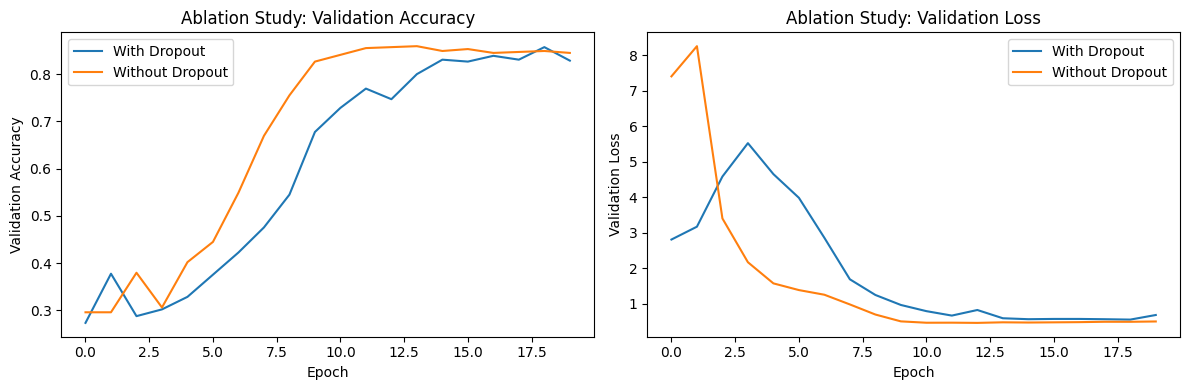

In [40]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(deeper_history.history["val_accuracy"], label="With Dropout")
plt.plot(no_dropout_history.history["val_accuracy"], label="Without Dropout")
plt.title("Ablation Study: Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(deeper_history.history["val_loss"], label="With Dropout")
plt.plot(no_dropout_history.history["val_loss"], label="Without Dropout")
plt.title("Ablation Study: Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


### Analyze how performance changes.

After removing dropout, the deeper CNN improved from 83.57% test accuracy to 88.08% test accuracy. The no-dropout model also achieved higher validation accuracy of 84.49%.

This shows that dropout did not improve performance in this experiment. The dropout version may have restricted learning too much, while the no-dropout model learned stronger features and achieved the best CNN result.


### Challenges and Observations

The main challenges were class imbalance, corrupted images, overfitting, and unstable validation loss. The Normal class had fewer images, so class weights were used. Corrupted images were removed before training.

The baseline CNN showed overfitting because training accuracy reached 100% while validation accuracy was lower. The deeper CNN with dropout improved slightly over the baseline, but the no-dropout deeper CNN achieved the best CNN performance with 88.08% test accuracy. Kaggle GPU acceleration was used during training.

## 2.6 Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

### 2.6.1 Loading and Adapting a Pre-Trained Model

In [41]:
def preprocess_for_mobilenet(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label


def make_mobilenet_dataset(dataframe, shuffle=False):
    paths = dataframe["file_path"].values
    labels = dataframe["label"].values.astype("int32")

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(preprocess_for_mobilenet, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_mobilenet_ds = make_mobilenet_dataset(train_df, shuffle=True)
val_mobilenet_ds = make_mobilenet_dataset(val_df, shuffle=False)
test_mobilenet_ds = make_mobilenet_dataset(test_df, shuffle=False)

The images were resized to 224 × 224 pixels and preprocessed using the MobileNetV2 preprocessing function.

In [42]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

transfer_model = keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.30),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

The original ImageNet classification layer was removed using include_top=False. New layers were added for four-class brain tumor classification.

The MobileNetV2 base was frozen first, so only the newly added classification layers were trained.


### 2.6.2 Model Training and Fine-Tuning


In [43]:
start_time = time.time()

transfer_history = transfer_model.fit(
    train_mobilenet_ds,
    validation_data=val_mobilenet_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

transfer_training_time = time.time() - start_time

print("Transfer learning training time:", transfer_training_time, "seconds")


Epoch 1/20


2026-05-03 15:26:48.059081: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:26:48.196072: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3931 - loss: 1.3156

2026-05-03 15:27:00.610268: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:27:00.746632: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.3943 - loss: 1.3135

2026-05-03 15:27:15.692414: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:27:15.829226: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 442ms/step - accuracy: 0.3954 - loss: 1.3115 - val_accuracy: 0.6796 - val_loss: 0.8809
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6522 - loss: 0.8450 - val_accuracy: 0.7469 - val_loss: 0.6981
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7243 - loss: 0.6967 - val_accuracy: 0.7714 - val_loss: 0.6333
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7485 - loss: 0.6185 - val_accuracy: 0.7837 - val_loss: 0.5896
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7880 - loss: 0.5277 - val_accuracy: 0.7816 - val_loss: 0.5647
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7904 - loss: 0.5035 - val_accuracy: 0.7959 - val_loss: 0.5430
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8015 - loss: 0.4638 - val_accuracy: 0.7980 - val_loss: 0.5198
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8224 - loss: 0.4232 - val_accuracy: 0.8082 - val_loss: 

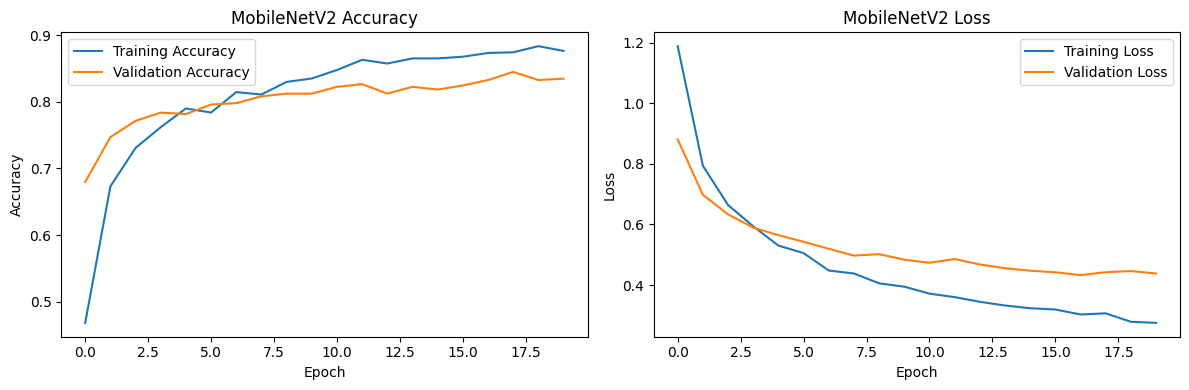

In [44]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(transfer_history.history["accuracy"], label="Training Accuracy")
plt.plot(transfer_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(transfer_history.history["loss"], label="Training Loss")
plt.plot(transfer_history.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The MobileNetV2 feature extraction model trained in about 87.96 seconds. The final training accuracy was about 88.21%, and the final validation accuracy was about 83.47%.

The validation loss decreased from 0.8809 to 0.4382, showing stable learning during training. MobileNetV2 trained faster than the deeper CNN models while maintaining good validation performance.

### 2.6.3 Model Evaluation and Prediction


In [45]:
transfer_y_true, transfer_y_pred = get_predictions(transfer_model, test_mobilenet_ds)

2026-05-03 15:28:18.124025: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 15:28:18.261073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


In [46]:
print("MobileNetV2 Classification Report:")
print(classification_report(transfer_y_true, transfer_y_pred, target_names=target_names))

MobileNetV2 Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.85      0.83      0.84       181
Meningioma Tumor       0.80      0.73      0.76       183
          Normal       0.87      0.94      0.91        88
 Pituitary Tumor       0.87      0.93      0.90       169

        accuracy                           0.84       621
       macro avg       0.85      0.86      0.85       621
    weighted avg       0.84      0.84      0.84       621



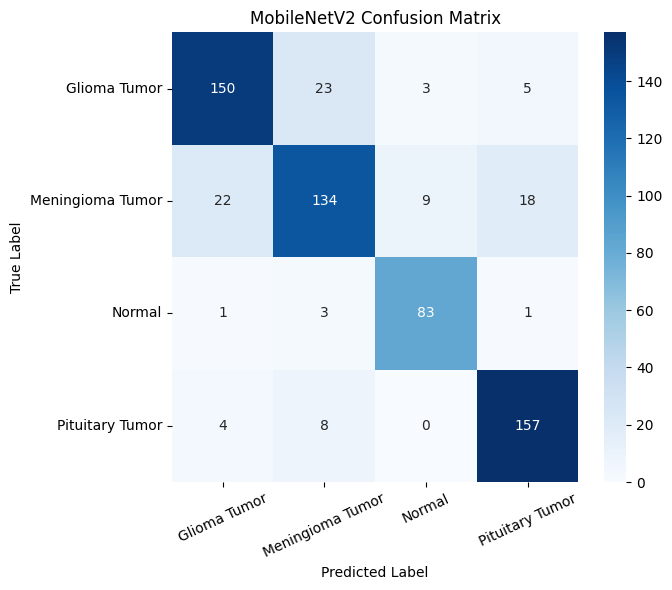

In [47]:
transfer_cm = confusion_matrix(transfer_y_true, transfer_y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    transfer_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=25)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Fine-Tuning MobileNetV2

After feature extraction, the top layers of MobileNetV2 were unfrozen and trained with a lower learning rate. This allows the pretrained model to adjust some high-level features to the MRI dataset.

In [51]:
for i, layer in enumerate(transfer_model.layers):
    print(i, layer.name, type(layer))

0 mobilenetv2_1.00_224 <class 'keras.src.models.functional.Functional'>
1 global_average_pooling2d <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
2 dropout_8 <class 'keras.src.layers.regularization.dropout.Dropout'>
3 dense_13 <class 'keras.src.layers.core.dense.Dense'>
4 dense_14 <class 'keras.src.layers.core.dense.Dense'>


In [52]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

fine_tune_history = transfer_model.fit(
    train_mobilenet_ds,
    validation_data=val_mobilenet_ds,
    epochs=5,
    class_weight=class_weights
)

fine_tune_training_time = time.time() - start_time

print("Fine-tuning training time:", fine_tune_training_time, "seconds")

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 33s 279ms/step - accuracy: 0.9128 - loss: 0.2259 - val_accuracy: 0.8327 - val_loss: 0.5060
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9134 - loss: 0.2047 - val_accuracy: 0.8327 - val_loss: 0.5022
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9236 - loss: 0.1882 - val_accuracy: 0.8347 - val_loss: 0.4955
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9445 - loss: 0.1537 - val_accuracy: 0.8408 - val_loss: 0.4760
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9524 - loss: 0.1449 - val_accuracy: 0.8388 - val_loss: 0.4756
Fine-tuning training time: 43.75916385650635 seconds


Fine-tuning trained the top MobileNetV2 layers for 5 epochs using a low learning rate. Training accuracy improved to about 95.24%, and validation accuracy reached about 83.88%.

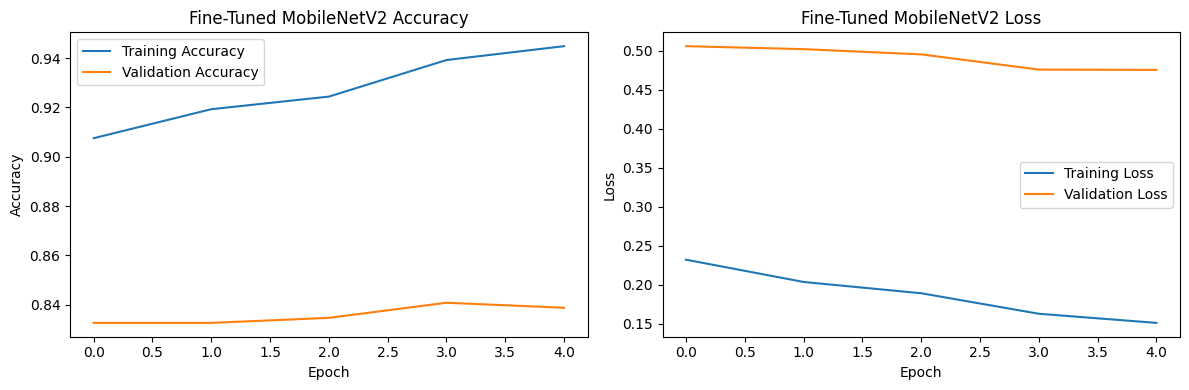

In [53]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(fine_tune_history.history["accuracy"], label="Training Accuracy")
plt.plot(fine_tune_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Fine-Tuned MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fine_tune_history.history["loss"], label="Training Loss")
plt.plot(fine_tune_history.history["val_loss"], label="Validation Loss")
plt.title("Fine-Tuned MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Fine-Tuned Model Evaluation

In [55]:
fine_tune_y_true, fine_tune_y_pred = get_predictions(transfer_model, test_mobilenet_ds)

print("Fine-Tuned MobileNetV2 Classification Report:")
print(classification_report(fine_tune_y_true, fine_tune_y_pred, target_names=target_names))

Fine-Tuned MobileNetV2 Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.88      0.88       181
Meningioma Tumor       0.89      0.70      0.79       183
          Normal       0.77      0.98      0.86        88
 Pituitary Tumor       0.87      0.95      0.91       169

        accuracy                           0.86       621
       macro avg       0.85      0.88      0.86       621
    weighted avg       0.86      0.86      0.86       621



The fine-tuned MobileNetV2 achieved 86% test accuracy. It performed well on pituitary tumor and glioma tumor, but meningioma tumor had lower recall of 0.70.

Fine-tuning improved the model compared with feature extraction in some classes, but it still did not outperform the no-dropout deeper CNN.

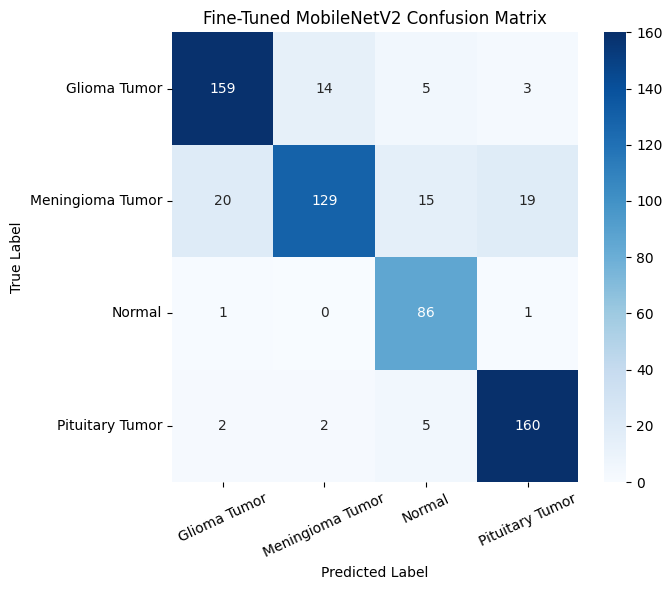

In [56]:
fine_tune_cm = confusion_matrix(fine_tune_y_true, fine_tune_y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    fine_tune_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Fine-Tuned MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=25)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [57]:
fine_tune_accuracy = np.mean(fine_tune_y_true == fine_tune_y_pred)

final_comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deeper CNN with Dropout",
        "Deeper CNN without Dropout",
        "MobileNetV2 Feature Extraction",
        "Fine-Tuned MobileNetV2"
    ],
    "Test Accuracy": [
        baseline_accuracy,
        deeper_accuracy,
        no_dropout_accuracy,
        transfer_accuracy,
        fine_tune_accuracy
    ],
    "Training Time (seconds)": [
        baseline_training_time,
        deeper_training_time,
        no_dropout_training_time,
        transfer_training_time,
        fine_tune_training_time
    ]
})

display(final_comparison)

,Model,Test Accuracy,Training Time (seconds)
0,Baseline CNN,0.829308,87.972164
1,Deeper CNN with Dropout,0.835749,236.163760
2,Deeper CNN without Dropout,0.880837,210.860702
3,MobileNetV2 Feature Extraction,0.843800,87.958047
4,Fine-Tuned MobileNetV2,0.859903,43.759164


### Final Model Comparison

The best test accuracy was achieved by the deeper CNN without dropout with 88.08%. Fine-tuned MobileNetV2 achieved 85.99%, while MobileNetV2 feature extraction achieved 84.38%.

The baseline CNN achieved 82.93%, and the deeper CNN with dropout achieved 83.57%. Overall, removing dropout from the deeper CNN gave the best classification performance.

### Discuss whether transfer learning outperforms training from scratch.

Fine-tuned MobileNetV2 achieved 85.99% test accuracy. This was better than the baseline CNN and the deeper CNN with dropout, but lower than the deeper CNN without dropout, which achieved 88.08%.

Therefore, transfer learning did not fully outperform the best model trained from scratch. However, fine-tuned MobileNetV2 still performed strongly and required less additional training time than training a deep CNN from scratch.

### Conclusion

This project successfully implemented brain tumor classification using CNN models and transfer learning. The dataset was cleaned by removing corrupted images, and class imbalance was handled using class weights.

Among all models, the deeper CNN without dropout achieved the highest test accuracy of 88.08%. Fine-tuned MobileNetV2 also performed well with 85.99% accuracy. Future improvements could include more hyperparameter tuning, testing other pretrained models such as ResNet50 or VGG16, and using explainable AI methods such as Grad-CAM.
